In [12]:
import os
import yfinance as yf
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error
import matplotlib.pyplot as plt

# 1. Define Constants for where data will live
STOCK_PATH = os.path.join("datasets", "stocks")

def fetch_stock_data(ticker, start_date="2023-01-01", end_date=None, stock_path=STOCK_PATH):
    """
    Downloads stock data from Yahoo Finance and saves it as a CSV file.
    """
    # Create the directory if it doesn't exist
    if not os.path.isdir(stock_path):
        os.makedirs(stock_path)
    
    # Construct the file path
    csv_path = os.path.join(stock_path, f"{ticker}.csv")
    
    # Download data using yfinance
    print(f"Downloading data for {ticker}...")
    data = yf.download(ticker, start=start_date, end=end_date, progress=False)
    
    # Save to CSV
    if not data.empty:
        data.to_csv(csv_path)
        print(f"Saved {ticker} data to {csv_path}")
    else:
        print(f"No data found for {ticker}")



In [13]:
def load_stock_data(ticker, stock_path=STOCK_PATH):
    """
    Loads the locally saved stock data CSV into a Pandas DataFrame.
    """
    csv_path = os.path.join(stock_path, f"{ticker}.csv")
    
    if not os.path.exists(csv_path):
        raise FileNotFoundError(f"No data found at {csv_path}.")
    
    # FIX: 
    # header=0    -> Use the first line (Price, Close, High...) as column names
    # skiprows=[1,2] -> Ignore the 'Ticker' and empty 'Date' rows
    # index_col=0 -> The first column is the Index
    df = pd.read_csv(csv_path, header=0, skiprows=[1, 2], index_col=0, parse_dates=True)
    
    # Optional: Rename the index from "Price" to "Date" for clarity
    df.index.name = "Date"
    
    return df

In [14]:
ticker="RGC"
fetch_stock_data(ticker, start_date="2023-01-01")
df = load_stock_data(ticker)
print(df.head())

C:\Users\dilip\AppData\Local\Temp\ipykernel_22760\2101643442.py:25: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start_date, end=end_date, progress=False)


Saved RGC data to datasets\stocks\RGC.csv
               Close      High       Low      Open  Volume
Date                                                      
2023-01-03  0.733947  0.733947  0.733947  0.733947       0
2023-01-04  0.733947  0.733947  0.733947  0.733947       0
2023-01-05  0.781842  0.788684  0.736842  0.736842   79800
2023-01-06  0.753158  0.777105  0.751316  0.777105   60800
2023-01-09  0.747368  0.774211  0.715789  0.763158   30400


In [15]:
import numpy as np
# --- NEW FUNCTION IMPLEMENTING YOUR FORMULA ---
def calculate_volatilitylog(df, M, dt=1/252):
    """
    Implements the annualized volatility formula:
    sigma = sqrt( (1 / ((M-1)*dt)) * sum( (R_i - R_bar)^2 ) )
    
    Parameters:
    df (pd.DataFrame): DataFrame containing 'Close' prices.
    M (int): The window size (number of observations).
    dt (float): Time step in years (default 1/252 for daily data).
    
    Returns:
    pd.Series: Rolling volatility values.
    """
    
    # 1. Calculate Log Returns: R_i = ln(Price_t / Price_{t-1})
    # We use 'Close' or 'Adj Close'
    df['Log_Return'] = np.log(df['Close'] / df['Close'].shift(1))

    
    # 2. Define the rolling window function
    # The formula is essentially: standard_deviation / sqrt(dt)
    # But let's implement it exactly as written algebraically for clarity.
    
    def formula_logic(window_data):
        # window_data represents the vector of R_i values of length M
        if len(window_data) < M: return np.nan
        
        R_bar = np.mean(window_data)
        sum_sq_diff = np.sum((window_data - R_bar)**2)
        
        # The term inside the square root
        variance_term = (1 / ((M - 1) * dt)) * sum_sq_diff
        
        return np.sqrt(variance_term)

    # 3. Apply rolling window
    # .rolling(M) creates windows of size M
    volatility = df['Log_Return'].rolling(window=M).apply(formula_logic, raw=True)
    
    return volatility

In [16]:
M_parameter = 20 # Example: 21 days (approx 1 trading month)
delta_t = 1/252  # Daily data
# Calculate
df['Volatility_M'] = calculate_volatilitylog(df, M=M_parameter, dt=delta_t)

print(f"Data with Volatility (M={M_parameter}):")
print(df[['Close', 'Log_Return', 'Volatility_M']].tail())

Data with Volatility (M=20):
                Close  Log_Return  Volatility_M
Date                                           
2025-12-08  16.980000    0.044559      0.955619
2025-12-09  16.600000   -0.022633      0.946758
2025-12-10  16.360001   -0.014563      0.937444
2025-12-11  16.850000    0.029511      0.906349
2025-12-15  16.950001    0.005917      0.877256


In [17]:
df['Lagged_Sq_Return'] = df['Log_Return'].shift(1) ** 2
# C. Target Creation: Realized Volatility of the *Next* 5 Days
    # We want to predict the std dev of returns from t+1 to t+5
    # shift(-5) looks into the future, so we must be careful not to leak data during training
indexer = pd.api.indexers.FixedForwardWindowIndexer(window_size=5)
df['Target_NextWeek_Vol'] = df['Log_Return'].rolling(window=indexer).std() * np.sqrt(252)
# Drop NaNs created by lagging/rolling
df_clean = df.dropna().copy()

    # D. Train/Test Split
    # We cannot use random shuffle for time series! We must split by time.
split_point = int(len(df_clean) * 0.8)
    
train_df = df_clean.iloc[:split_point]
test_df = df_clean.iloc[split_point:]

X_train = train_df[['Volatility_M', 'Lagged_Sq_Return']]
y_train = train_df['Target_NextWeek_Vol']
    
X_test = test_df[['Volatility_M', 'Lagged_Sq_Return']]
y_test = test_df['Target_NextWeek_Vol']


In [18]:
# E. Baseline Model
    # Prediction: "Next week's volatility will be the same as today's 21-day volatility"
y_pred_baseline = X_test['Volatility_M']

In [19]:
# F. Random Forest Model
rf = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

--- Results for RGC ---
Baseline RMSE: 2.2697
ML Model RMSE: 2.2595
SUCCESS: ML Model beat the baseline!


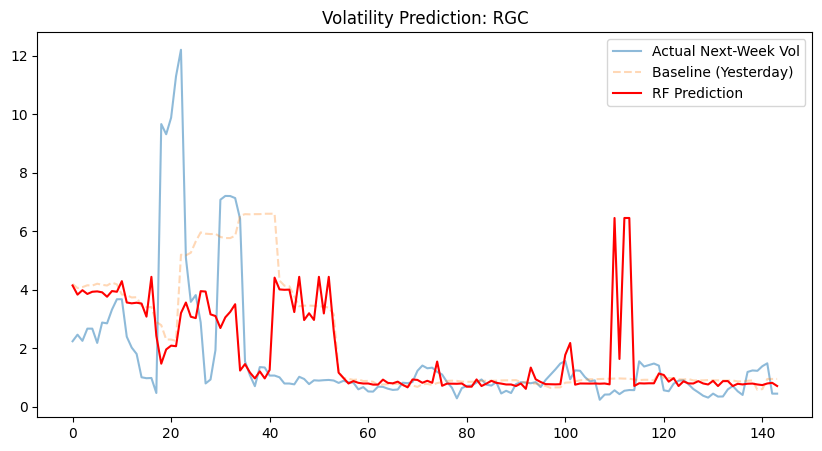

In [20]:
# G. Evaluation
rmse_baseline = root_mean_squared_error(y_test, y_pred_baseline)
rmse_rf = root_mean_squared_error(y_test, y_pred_rf)

print(f"--- Results for {ticker} ---")
print(f"Baseline RMSE: {rmse_baseline:.4f}")
print(f"ML Model RMSE: {rmse_rf:.4f}")
    
if rmse_rf < rmse_baseline:
        print("SUCCESS: ML Model beat the baseline!")
else:
        print("FAIL: Baseline is stronger (Market is efficient/Noisy).")

# Optional: Plotting
plt.figure(figsize=(10, 5))
plt.plot(y_test.values, label='Actual Next-Week Vol', alpha=0.5)
plt.plot(y_pred_baseline.values, label='Baseline (Yesterday)', alpha=0.3, linestyle='--')
plt.plot(y_pred_rf, label='RF Prediction', color='red')
plt.legend()
plt.title(f"Volatility Prediction: {ticker}")
plt.show()


In [21]:
import ctypes
import os
import pandas as pd
import numpy as np

# --- 1. Load the Shared Library ---
lib_name = "libmontecarlo.dll" if os.name == 'nt' else "libmontecarlo.so"
lib_path = os.path.abspath(lib_name)

try:
    c_lib = ctypes.CDLL(lib_path)
    print(f"Loaded library: {lib_path}")
except OSError as e:
    print(f"Error: {e}")
    
# --- 2. Define Argument Types ---
# void run_simulation(S0, K, r, sigma, T, steps, sims, seed, results)
c_lib.run_simulation.argtypes = [
    ctypes.c_double, # S0
    ctypes.c_double, # K
    ctypes.c_double, # r
    ctypes.c_double, # sigma
    ctypes.c_double, # T
    ctypes.c_int,    # steps
    ctypes.c_int,    # sims
    ctypes.c_int,    # seed
    ctypes.POINTER(ctypes.c_double) # results array
]

# --- 3. Wrapper Functions ---
def get_simulation_results(S0, K, r, sigma, T, steps=1000, sims=100000, seed=42):
    results_array = (ctypes.c_double * 3)()
    c_lib.run_simulation(S0, K, r, sigma, T, steps, sims, seed, results_array)
    return {
        "Call": results_array[0],
        "Put": results_array[1],
        "Asian": results_array[2]
    }

def calculate_delta(S0, K, r, sigma, T, steps=1000, sims=100000):
    epsilon = S0 * 0.01
    fixed_seed = 12345 
    
    # Run 1: Base Price
    base_res = get_simulation_results(S0, K, r, sigma, T, steps, sims, seed=fixed_seed)
    
    # Run 2: Bumped Price (Same Random Seed)
    bump_res = get_simulation_results(S0 + epsilon, K, r, sigma, T, steps, sims, seed=fixed_seed)
    
    delta = {}
    for key in base_res:
        delta[key] = (bump_res[key] - base_res[key]) / epsilon
    return delta

# --- 5. Main Execution with REAL DATA ---

# A. Retrieve Data from Previous Cells
try:
    # 1. Get Stock Price
    current_price = df['Close'].iloc[-1]
    if isinstance(current_price, pd.Series):
        current_price = current_price.item()
        
    # 2. Get Predicted Volatility
    predicted_vol = y_pred_rf[-1] 
    
    # 3. Identify Ticker
    ticker_name = ticker if 'ticker' in globals() else 'Unknown'
    
except NameError:
    print("WARNING: 'df' or 'y_pred_rf' not found. Using dummy data.")
    current_price = 100.0
    predicted_vol = 0.20
    ticker_name = "TEST"

# B. Set Trade Parameters
S = float(current_price)       # From Data
K = S * 1.05                   # Strike = 5% OTM
r = 0.05                       # Risk-Free Rate
vol = float(predicted_vol)     # From ML Model
T = 1.0                        # 1 Year Expiry

# --- PRINTING PARAMETERS ---
print(f"\n--- Simulation Parameters ({ticker_name}) ---")
print(f"   Asset Price (S0):   ${S:.2f}")
print(f"   Strike Price (K):   ${K:.2f}")
print(f"   Risk-Free Rate (r): {r*100:.1f}%")
print(f"   Volatility (ML):    {vol*100:.2f}%")  # <--- This verifies your ML input
print(f"   Time to Maturity:   {T} Year")
print("-" * 30)

# C. Get Prices
prices = get_simulation_results(S, K, r, vol, T)

print(f"\n--- Option Prices (C Engine) ---")
print(f"European Call: ${prices['Call']:.4f}")
print(f"European Put:  ${prices['Put']:.4f}")
print(f"Asian Call:    ${prices['Asian']:.4f}")

# D. Get Delta
deltas = calculate_delta(S, K, r, vol, T)

print(f"\n--- Option Delta (Sensitivity) ---")
print(f"European Call Delta: {deltas['Call']:.4f}")
print(f"European Put Delta:  {deltas['Put']:.4f}")
print(f"Asian Call Delta:    {deltas['Asian']:.4f}")

Loaded library: c:\Users\dilip\testing\libmontecarlo.dll

--- Simulation Parameters (RGC) ---
   Asset Price (S0):   $16.95
   Strike Price (K):   $17.80
   Risk-Free Rate (r): 5.0%
   Volatility (ML):    71.47%
   Time to Maturity:   1.0 Year
------------------------------

--- Option Prices (C Engine) ---
European Call: $4.7472
European Put:  $4.7067
Asian Call:    $2.5514

--- Option Delta (Sensitivity) ---
European Call Delta: 0.6470
European Put Delta:  -0.3561
Asian Call Delta:    0.5373


Fetching Data...


C:\Users\dilip\AppData\Local\Temp\ipykernel_22760\389092549.py:31: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start="2023-01-01", end="2024-01-01", progress=False)


Training ML Model...
Running C-Engine Backtest...


C:\Users\dilip\AppData\Local\Temp\ipykernel_22760\389092549.py:25: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  c_lib.run_simulation(S, K, r, sigma, T, 100, 10000, seed, results)


Total Backtest PnL: $0.01


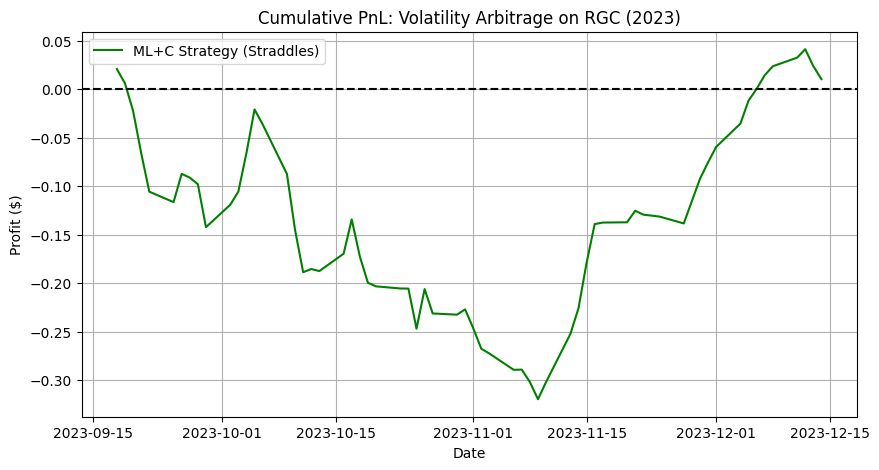

In [22]:
import ctypes
import os
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor

# --- A. C-Types Wrapper Setup ---
lib_name = "libmontecarlo.dll" if os.name == 'nt' else "libmontecarlo.so"
try:
    c_lib = ctypes.CDLL(os.path.abspath(lib_name))
    c_lib.run_simulation.argtypes = [
        ctypes.c_double, ctypes.c_double, ctypes.c_double, ctypes.c_double, 
        ctypes.c_double, ctypes.c_int, ctypes.c_int, ctypes.c_int, 
        ctypes.POINTER(ctypes.c_double)
    ]
except Exception as e:
    print(f"Library Error: {e}. Please compile the C code first!")

def get_straddle_price(S, K, r, sigma, T, seed=42):
    """Calculates Price of ATM Straddle (Call + Put) using C Engine"""
    results = (ctypes.c_double * 3)()
    # Run Simulation (10k sims for speed in loop)
    c_lib.run_simulation(S, K, r, sigma, T, 100, 10000, seed, results)
    # Return Call + Put
    return results[0] + results[1]

# --- B. Data Pipeline (AAPL 2023) ---
print("Fetching Data...")
df = yf.download(ticker, start="2023-01-01", end="2024-01-01", progress=False)

# 1. Feature Engineering
df['Log_Ret'] = np.log(df['Close'] / df['Close'].shift(1))
df['Hist_Vol_20'] = df['Log_Ret'].rolling(20).std() * np.sqrt(252) # "Market" Vol
df['Target_Vol_5d'] = df['Log_Ret'].rolling(5).std().shift(-5) * np.sqrt(252) # Truth

# 2. Clean and Split
df = df.dropna()
split = int(len(df) * 0.7) # 70% Train (Jan-Aug), 30% Test (Sep-Dec)
train_df = df.iloc[:split]
test_df = df.iloc[split:].copy()

# 3. ML Training
print("Training ML Model...")
rf = RandomForestRegressor(n_estimators=50, max_depth=5, random_state=42)
X_train = train_df[['Hist_Vol_20']] # Simple feature for demo
y_train = train_df['Target_Vol_5d']
rf.fit(X_train, y_train)

# 4. Predict
test_df['Pred_Vol'] = rf.predict(test_df[['Hist_Vol_20']])

# --- C. Backtest Loop ---
print("Running C-Engine Backtest...")
pnl_history = []
positions = []

# Constants
r = 0.05
T_weeks = 5/252 # 1 week expiration

for i in range(len(test_df) - 5): # Stop 5 days before end to allow settlement
    row = test_df.iloc[i]
    future_row = test_df.iloc[i+5]
    
    S0 = row['Close'].item() if isinstance(row['Close'], pd.Series) else row['Close']
    K = S0 # ATM Straddle
    
    # 1. PRICING
    # Market Price: Uses Historical Vol (Backward looking)
    # Model Price: Uses ML Predicted Vol (Forward looking)
    mkt_price = get_straddle_price(S0, K, r, row['Hist_Vol_20'], T_weeks)
    model_price = get_straddle_price(S0, K, r, row['Pred_Vol'], T_weeks)
    
    # 2. TRADING LOGIC
    # If ML predicts HIGHER vol than history -> Buy Straddle (Long Vol)
    # If ML predicts LOWER vol than history -> Sell Straddle (Short Vol)
    if model_price > mkt_price:
        position = 1 # Long
    else:
        position = -1 # Short
        
    # 3. SETTLEMENT (5 Days Later)
    # Value = Abs(Price_Final - Strike)
    S_final = future_row['Close'].item() if isinstance(future_row['Close'], pd.Series) else future_row['Close']
    intrinsic_value = abs(S_final - K)
    
    # 4. PnL CALCULATION
    if position == 1:
        # Long: Profit = Exit Value - Entry Cost
        pnl = intrinsic_value - mkt_price
    else:
        # Short: Profit = Entry Cost - Exit Value
        pnl = mkt_price - intrinsic_value
        
    pnl_history.append(pnl)
    positions.append(position)

# --- D. Analysis ---
test_df = test_df.iloc[:len(pnl_history)]
test_df['PnL'] = pnl_history
test_df['Cum_PnL'] = test_df['PnL'].cumsum()

print(f"Total Backtest PnL: ${test_df['Cum_PnL'].iloc[-1]:.2f}")

# Plot
plt.figure(figsize=(10, 5))
plt.plot(test_df.index, test_df['Cum_PnL'], label='ML+C Strategy (Straddles)', color='green')
plt.title(f"Cumulative PnL: Volatility Arbitrage on {ticker} (2023)")
plt.xlabel("Date")
plt.ylabel("Profit ($)")
plt.axhline(0, color='black', linestyle='--')
plt.legend()
plt.grid(True)
plt.show()